In [33]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.ess import compute_ess

In [34]:
sns.set_style("darkgrid")

In [35]:
PATH = Path("..")

In [36]:
method_names = {"beauti", "guided_transport", "targeted"}

In [37]:
experiment = "hcv"

In [38]:
columns_per_experiment = {
    "apes": ["posterior", "treeLikelihood.1stpos", "Tree.treeLength", "birthRate", "gammaShape", "kappa", "freqParameter.1"],
    "pas": ['posterior', 'prior', 'treeLikelihood.1', 'Tree.height', 'Tree.treeLength', 'mutationRate.1', 'ORCsigma', 'ORCRatesStat.mean','BirthDeath', 'BDBirthRate', 'BDDeathRate'],
    "hcv":  ["posterior", "treeLikelihood", "Tree.treeLength", "gammaShape", "rateAG", "freqParameter.1", "bPopSizes.1", "bGroupSizes.2", "BayesianSkyline"],
    "rsv2": ["posterior", "treeLikelihood.1", "Tree.treeLength", "mutationRate.1", "rateAC.1", "gammaShape.1", "ORCucldMean", "freqParameter.1.3", "popSize"],
    "h3n2": ["posterior", "prior", "likelihood", "Tree.treeLength", "ORCucldMean", "gammaShape", "popSize"],
}

In [39]:
def get_ess_df(log_df: pd.DataFrame, column: str, method: str):
    ess_dict = {
        "i": [],
        "ess": [],
        "column": [],
        "method": [],
    }

    burnin = len(log_df) // 10
    col_values = log_df[column].values[burnin:]

    for i in range(0, len(col_values), 40):
        # estimate ESS for log_df[:i+1, column]
        try:
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ess_val = compute_ess(col_values[:i+1])
       
            ess_dict["i"].append(i)
            ess_dict["ess"].append(ess_val)
            ess_dict["column"].append(column)
            ess_dict["method"].append(method)
        except Exception:
            pass

    return pd.DataFrame(ess_dict)

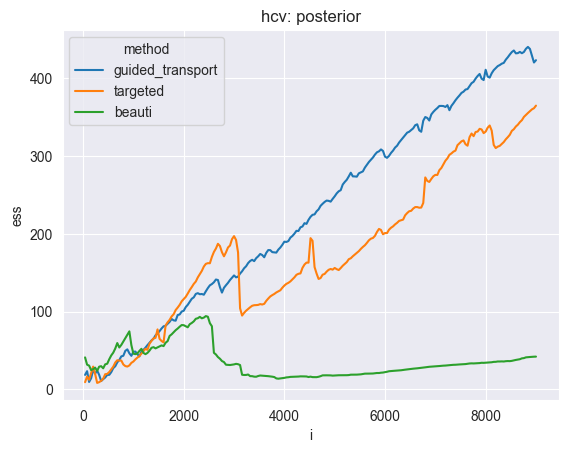

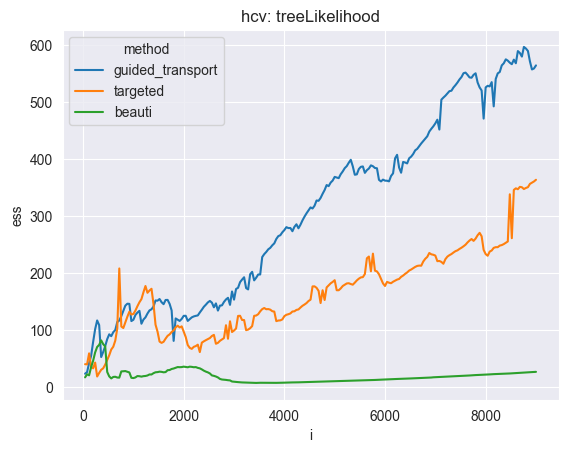

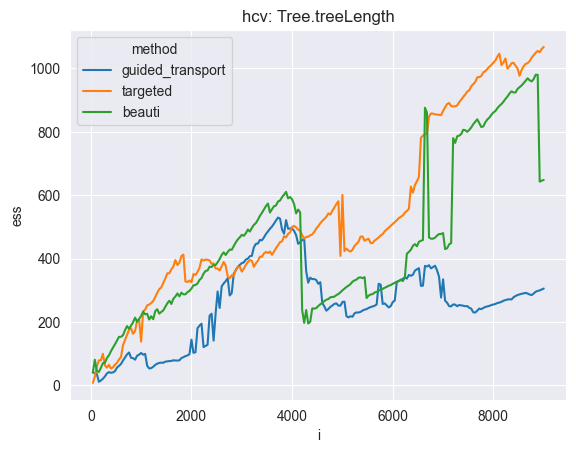

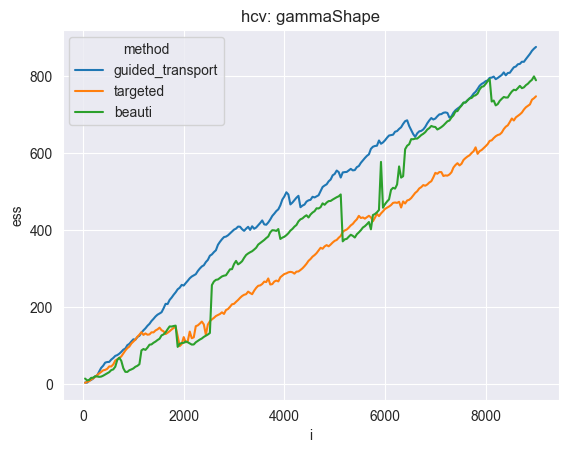

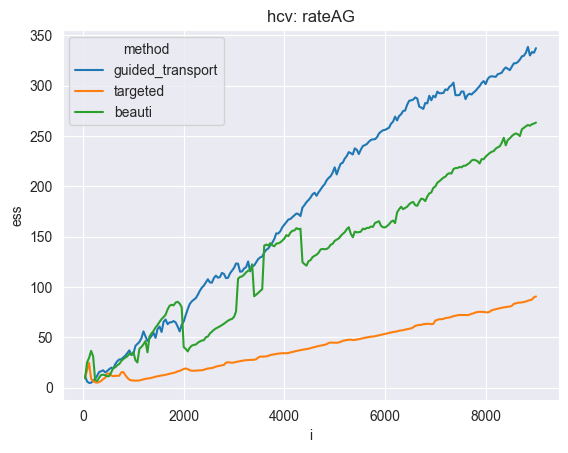

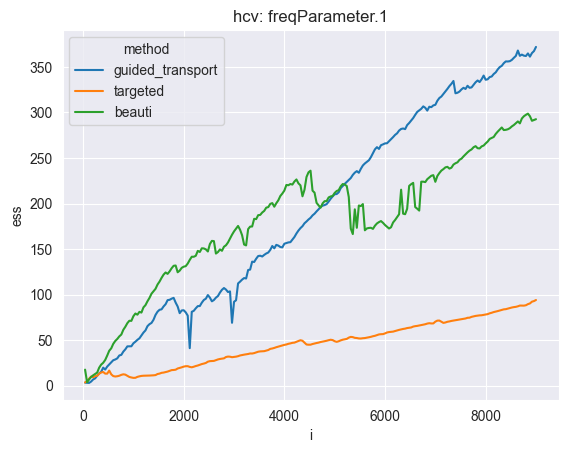

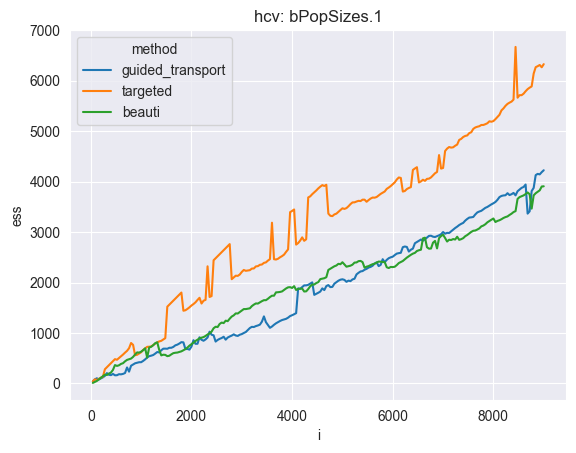

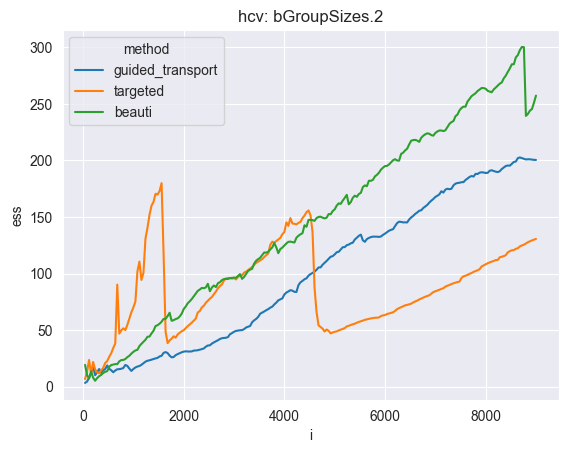

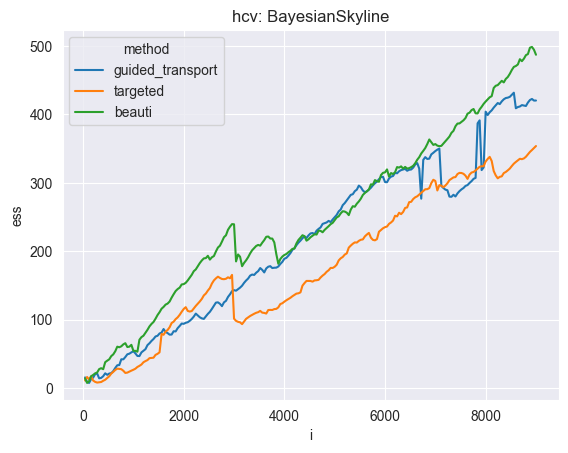

In [40]:
ess_dfs = []

for method in method_names:
        log_dfs = [
            pd.read_csv(path, comment="#", delimiter="\t") for path in PATH.glob(f"{experiment}_{method}-1.log")
        ]

        for column in columns_per_experiment[experiment]:
            try:
                ess_dfs += [
                    get_ess_df(log_df, column, method) for log_df in log_dfs
                ]
            except KeyError:
                ...
                
ess_df = pd.concat(ess_dfs)

for column in columns_per_experiment[experiment]:
    # Drop duplicate index labels that may cause seaborn to fail
    data = ess_df[ess_df.column == column].copy()
    data = data.reset_index(drop=True)
    sns.lineplot(data, x="i", y="ess", hue="method")
    plt.title(f"{experiment}: {column}")
    plt.show()